In [114]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import toy_models
import matplotlib.cm as cm

In [115]:
# 1. Global NeurIPS Formatting Parameters
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": (5.5, 2.4), 
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
})

# Section 1

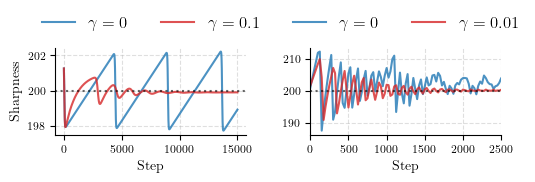

In [106]:
x0=2.0
y0=1
z0=0
lr=0.01
alpha=0.1
beta=1.5
n_steps=15000
lambdas = [0, 0.1]

# 3. Create 1x3 Subplots
fig, axes = plt.subplots(1, 2, sharey=False)

# Colors: using a colorblind-friendly approach
color_blue = '#1f77b4'  # Muted Blue
color_red = '#d62728' # Brick Red
color_steady = 'black'


data_0 = toy_models.gd_run(
    x0=x0,
    y0=y0,
    z0=z0,
    lr=0.01,
    wd=0,
    alpha=alpha,
    beta=beta,
    n_steps=n_steps,
)
data_1 = toy_models.gd_run(
    x0=x0,
    y0=y0,
    z0=z0,
    lr=0.01,
    wd=0.1,
    alpha=alpha,
    beta=beta,
    n_steps=n_steps,
)

gd_directory_0 = "slt-results/cifar10-5k/cnn-relu/seed_10_true/mse/gd/lr_0.01/wd_0"
gd_directory_1 = "slt-results/cifar10-5k/cnn-relu/seed_10_true/mse/gd/lr_0.01/wd_0.01"
threshold = 200

gd_s_0 = torch.load(f"{gd_directory_0}/eigs_final.pt")
sharpness_0 = gd_s_0[:,0].numpy() if hasattr(gd_s_0, 'numpy') else np.array(gd_s_0)

gd_s_1 = torch.load(f"{gd_directory_1}/eigs_final.pt")
sharpness_1 = gd_s_1[:,0].numpy() if hasattr(gd_s_1, 'numpy') else np.array(gd_s_1)

# Isolate data after crossing the threshold
first_above = np.argmax(sharpness_0 > threshold)
if first_above > 0 or sharpness_0[0] > threshold:
    sharpness_cut = sharpness_0[first_above:]
    steps = np.arange(len(sharpness_cut)) * 25
    
    axes[1].plot(
        steps,
        sharpness_cut,
        linestyle='-',
        color=color_blue,
        alpha=0.8,
        label=r'$\gamma=0$'
    )

first_above = np.argmax(sharpness_1 > threshold)
if first_above > 0 or sharpness_1[0] > threshold:
    sharpness_cut = sharpness_1[first_above:]
    steps = np.arange(len(sharpness_cut)) * 25
    
    axes[1].plot(
        steps,
        sharpness_cut,
        linestyle='-',
        color=color_red,
        alpha=0.8,
        label=r'$\gamma=0.01$'
    )


axes[0].plot(np.arange(n_steps+1), data_0["S"], linestyle='-', color=color_blue, alpha=0.8, label=r'$\gamma=0$')
axes[0].plot(np.arange(n_steps+1), data_1["S"], linestyle='-', color=color_red, alpha=0.8, label=r'$\gamma=0.1$')
axes[0].axhline(200, linestyle=':', color=color_steady, alpha=0.6)
axes[1].axhline(200, linestyle=':', color=color_steady, alpha=0.6)

axes[0].set_ylabel('Sharpness')
axes[0].set_xlabel('Step')
axes[1].set_xlabel('Step')

axes[1].set_xlim(0,2500)

axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# 2. NEW: Add legends above each subplot
# loc='lower center' combined with y=1.02 in bbox_to_anchor places the bottom of the legend just above the plot
# ncol sets the items to display horizontally
axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)
axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)

# 4. Export safely with tight bounding box
plt.tight_layout()
plt.savefig('plots/intro_dampening.pdf', format='pdf', bbox_inches='tight')
plt.show()

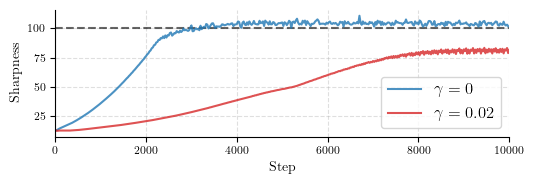

In [88]:
# 2. Setup Data Parameters
gd_lr = 0.02
freq = 25
wd = [0, 0.02]
threshold = 2 / gd_lr
all_sharpness = []

# Extract Data
for w_d in wd:
    gd_directory = f"slt-results/cifar10-5k/full_200/seed_10/mse/gd/lr_0.02/wd_{w_d}"
    gd_s = torch.load(f"{gd_directory}/eigs_final.pt")

    sharpness = gd_s[:,0].numpy() if hasattr(gd_s, 'numpy') else np.array(gd_s)
    first_above = np.argmax(sharpness > threshold)
    all_sharpness.append(sharpness)

# 3. Create a Single Plot
fig, ax = plt.subplots()

# Colors: Muted Blue and Brick Red
colors = ['#1f77b4', '#d62728']

# Plot the threshold line once
ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.6)

for w_d, sharpness, color in zip(wd, all_sharpness, colors):
    steps = np.arange(len(sharpness)) * freq
    ax.plot(
        steps,
        sharpness,
        linestyle='-',
        color=color,
        alpha=0.8,
        label=rf'$\gamma = {w_d}$' # Using \gamma as per your original CNN script
    )

# Formatting the axis
ax.set_xlabel('Step')
ax.set_ylabel('Sharpness')
ax.set_xlim(0, 10000)

# Legend positioned above the plot
ax.legend(
    loc='lower right',
    # bbox_to_anchor=(0.5, 1.0),  # Centers it just above the top spine
    # ncol=2,                     # Places items side-by-side (will wrap to 2 rows for 3 items)
    # frameon=False,
    fontsize=12
)

# Clean up grid and spines
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. Export safely with tight bounding box
plt.tight_layout()
plt.savefig('plots/intro_phaseshift.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Section 3

/tmp/ipykernel_17501/4253661301.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu')


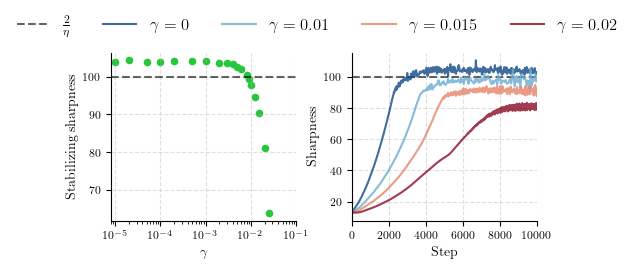

In [89]:
# Initialize 1x2 Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 2))

# Shared Parameters
dataset = "cifar10-5k"
arch = "full_200"
loss = "mse"
gd_lr = 0.02
seed = 10
threshold = 2 / gd_lr

# Generate 4 colorblind-friendly colors from RdBu for the lines
cmap = cm.get_cmap('RdBu')
gradient_colors = [cmap(0.95), cmap(0.75), cmap(0.25), cmap(0.05)]

# ==========================================
# PLOT 1: Stabilizing Sharpness (Left - ax1)
# ==========================================
df = pd.read_csv(f"dataframes/gd_{gd_lr}_{seed}.csv")
df = df.sort_values("lam").reset_index(drop=True)
df = df[df["lam"] != 0.03]

# EoS Label exclusively added here to avoid duplicates
ax1.axhline(y=threshold, color='black', linestyle='--', alpha=0.6, label=r"$\frac{2}{\eta}$")

# Changed scatter color to requested green
ax1.scatter(df["lam"], df["mean"], color='#28c63d', s=20)

ax1.set_ylabel("Stabilizing sharpness")
ax1.set_xlabel(r'$\gamma$')
ax1.set_xscale("log")
ax1.set_xlim(0.8e-5, 1e-1)

# Formatting ax1
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


# ==========================================
# PLOT 2: MLP Trajectories (Right - ax2)
# ==========================================
wd_list = [0, 0.01, 0.015, 0.02]

# Plotted without label so it doesn't duplicate in the global legend
ax2.axhline(y=threshold, color='black', linestyle='--', alpha=0.6)

for w_d, color in zip(wd_list, gradient_colors):
    results_dir = os.environ.get('RESULTS', 'slt-results')
    gd_directory = f"{results_dir}/{dataset}/{arch}/seed_{seed}/{loss}/gd/lr_{gd_lr}/wd_{w_d}"
    
    try:
        gd_s = torch.load(f"{gd_directory}/eigs_final.pt")
    except FileNotFoundError:
        print(f"Warning: Could not find {gd_directory}/eigs_final.pt")
        continue

    if w_d in [0.01, 1e-5, 1e-4, 1e-3, 0.001, 0.03]:
        freq = 50
    else:
        freq = 25
        
    xs = torch.arange(len(gd_s)) * freq

    ax2.plot(
        xs, gd_s, 
        linestyle='-', color=color, alpha=0.8, 
        label=rf'$\gamma={w_d}$'
    )

ax2.set_ylabel('Sharpness')
ax2.set_xlabel('Step')
ax2.set_xlim(0, 10000)

# Formatting ax2
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# ==========================================
# Single Shared Legend (Placed Above)
# ==========================================
# Extract handles and labels from both subplots
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Create a figure-level legend combining all elements
fig.legend(
    handles1 + handles2, 
    labels1 + labels2, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.95),  # Centered above the plots
    ncol=5,                      # 5 columns (1 EoS + 4 Gammas) to fit in one row horizontally
    frameon=False, 
    fontsize=12
)

# ==========================================
# Final Export and Display
# ==========================================
# Added top=0.85 to make room for the figure legend above the plots
plt.subplots_adjust(top=0.95, wspace=0.3)
plt.savefig('plots/empirical_stabilizing_sharpness.pdf', format='pdf', bbox_inches='tight')
plt.show()

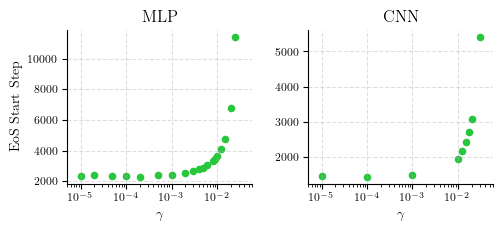

In [90]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# 1. Global NeurIPS Formatting Parameters
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": (5.5, 2), 
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
})

def first_nonmonotone(loss: torch.Tensor, eps: float = 0):
    """Returns the first step i where loss[i] > loss[i-1] + eps, or None."""
    loss = loss.detach().flatten()
    d = loss[1:] - loss[:-1]
    idx = torch.nonzero(d > eps, as_tuple=False)
    return (idx[0].item() + 1) if idx.numel() else None

RESULTS = 'slt-results'
DATASET = "cifar10-5k"
LOSS = "mse"

# --- CNN config ---
CNN_ARCH = "cnn-relu"
CNN_LR = 0.01
CNN_SEED = "10_true"
CNN_WD = [1e-5, 1e-4, 1e-3, 1e-2, 1.25e-2, 1.5e-2, 1.75e-2, 2e-2, 3e-2]

# --- MLP config ---
MLP_ARCH = "full_200"
MLP_LR = 0.02
MLP_SEED = 10
MLP_DF = pd.read_csv(f"dataframes/gd_{MLP_LR}_{MLP_SEED}.csv")
MLP_DF = MLP_DF[MLP_DF["lam"] != 0.03]
MLP_WD = MLP_DF.sort_values("lam")["lam"].tolist()

def collect_eos(arch, lr, seed, wd_list):
    wd_vals, eos_vals = [], []
    for wd in wd_list:
        path = f"{RESULTS}/{DATASET}/{arch}/seed_{seed}/{LOSS}/gd/lr_{lr}/wd_{wd}"
        
        try:
            train_loss = torch.load(f"{path}/train_loss_final.pt")
            eos = first_nonmonotone(train_loss)
            if eos is not None:
                wd_vals.append(wd)
                eos_vals.append(eos)
        except FileNotFoundError:
            print(f"Warning: Could not find train_loss_final.pt for wd={wd}")
            continue
            
    return wd_vals, eos_vals

cnn_wd, cnn_eos = collect_eos(CNN_ARCH, CNN_LR, CNN_SEED, CNN_WD)
mlp_wd, mlp_eos = collect_eos(MLP_ARCH, MLP_LR, MLP_SEED, MLP_WD)

all_wd = cnn_wd + mlp_wd
x_min, x_max = min(all_wd), max(all_wd)

# Initialize 1x2 Subplots
fig, axes = plt.subplots(1, 2, sharey=False)

for ax, wd_vals, eos_vals, title in zip(
    axes,
    [mlp_wd, cnn_wd],
    [mlp_eos, cnn_eos],
    ["MLP", "CNN"],
):
    ax.scatter(wd_vals, eos_vals, color="#28c63d", s=20)
    ax.set_xscale("log")
    ax.set_xlim(x_min * 0.5, x_max * 2)
    ax.set_xlabel(r"$\gamma$")
    ax.set_title(title, fontsize=12)
    
    # Clean up grid and spines to match previous style
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel("EoS Start Step")

# Final Export and Display
plt.subplots_adjust(wspace=0.3)
# Note: Saving as PDF matches the vector format from earlier figures, 
# but you can change 'pdf' back to 'png' if you prefer rasterized output.
plt.savefig("plots/empirical_slowdown_scale.pdf", format="pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_17501/3172219529.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu')


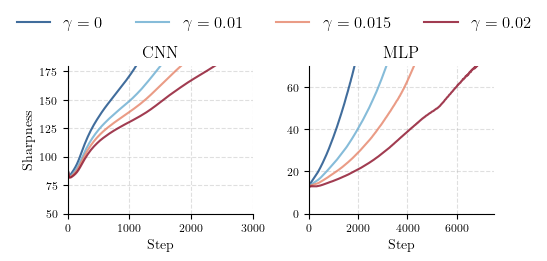

In [91]:
# Initialize 1x2 Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 2))

# Generate 4 colorblind-friendly colors from RdBu
cmap = cm.get_cmap('RdBu')
gradient_colors = [cmap(0.95), cmap(0.75), cmap(0.25), cmap(0.05)]

# Shared values representing the spread of gammas
wd_list = [0, 0.01, 0.015, 0.02]
dataset = "cifar10-5k"
loss = "mse"

# ==========================================
# PLOT 1: CNN Trajectories (Left - ax1)
# ==========================================
cnn_arch = "cnn-relu"
cnn_lr = 0.01
cnn_seed = "10_true"

# We still plot the threshold so it appears in the legend, 
# even though it (y=200) will be cut off by our ylim

for w_d, color in zip(wd_list, gradient_colors):
    results_dir = 'slt-results'
    gd_directory = f"{results_dir}/{dataset}/{cnn_arch}/seed_{cnn_seed}/{loss}/gd/lr_{cnn_lr}/wd_{w_d}"
    
    try:
        gd_s = torch.load(f"{gd_directory}/eigs_final.pt")
        # Ensure it's a numpy array to plot
        sharpness = gd_s[:,0].numpy() if hasattr(gd_s, 'numpy') else np.array(gd_s)
        
        freq = 25
        xs = np.arange(len(sharpness)) * freq

        ax1.plot(
            xs, sharpness, 
            linestyle='-', color=color, alpha=0.8, 
            label=rf'$\gamma={w_d}$'
        )
    except FileNotFoundError:
        print(f"Warning: Could not find CNN eigs_final.pt for wd={w_d}")

# Cap sharpness at 80 to show PS slowdown
ax1.set_ylim(50, 180)
ax1.set_xlim(0, 3000)
ax1.set_ylabel('Sharpness')
ax1.set_xlabel('Step')
ax1.set_title('CNN', fontsize=12)

ax1.grid(True, linestyle='--', alpha=0.4)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


# ==========================================
# PLOT 2: MLP Trajectories (Right - ax2)
# ==========================================
mlp_arch = "full_200"
mlp_lr = 0.02
mlp_seed = 10

for w_d, color in zip(wd_list, gradient_colors):
    results_dir = os.environ.get('RESULTS', 'slt-results')
    gd_directory = f"{results_dir}/{dataset}/{mlp_arch}/seed_{mlp_seed}/{loss}/gd/lr_{mlp_lr}/wd_{w_d}"
    
    try:
        gd_s = torch.load(f"{gd_directory}/eigs_final.pt")
        sharpness = gd_s[:,0].numpy() if hasattr(gd_s, 'numpy') else np.array(gd_s)

        if w_d in [0.01, 1e-5, 1e-4, 1e-3, 0.001, 0.03]:
            freq = 50
        else:
            freq = 25
            
        xs = np.arange(len(sharpness)) * freq

        ax2.plot(
            xs, sharpness, 
            linestyle='-', color=color, alpha=0.8
        )
    except FileNotFoundError:
        print(f"Warning: Could not find MLP eigs_final.pt for wd={w_d}")

# Cap sharpness at 80 to show PS slowdown
ax2.set_ylim(0, 70)
ax2.set_xlim(0, 7500)
ax2.set_xlabel('Step')
ax2.set_title('MLP', fontsize=12)

ax2.grid(True, linestyle='--', alpha=0.4)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# ==========================================
# Single Shared Legend (Placed Above)
# ==========================================
handles1, labels1 = ax1.get_legend_handles_labels()

fig.legend(
    handles1, 
    labels1, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.95),
    ncol=4,
    frameon=False, 
    fontsize=12
)

# ==========================================
# Final Export and Display
# ==========================================
plt.subplots_adjust(top=0.85, wspace=0.3)
plt.savefig('plots/empirical_slowdown_shown.pdf', format='pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_17501/3970573994.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu')


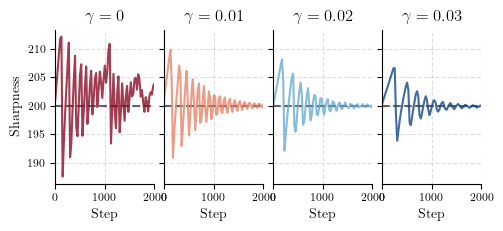

In [92]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# 1. Global NeurIPS Formatting Parameters
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    # Width expanded to ~11 inches to comfortably fit 4 subplots
    "figure.figsize": (5.5, 2), 
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
})

# 2. Setup Data Parameters
dataset = "cifar10-5k"
arch = "cnn-relu"
loss = "mse"
gd_lr = 0.01
seed = '10_true'
freq = 25
threshold = 2 / gd_lr

# Decreasing gamma values as requested
wd_list = [0, 0.01, 0.02, 0.03] 

# Generate 4 colorblind-friendly colors from RdBu
cmap = cm.get_cmap('RdBu')
gradient_colors = [cmap(0.05), cmap(0.25), cmap(0.75), cmap(0.95)] # Red to Blue

# 3. Create 1x4 Subplots (Sharing Y-axis to easily compare dampening magnitude)
fig, axes = plt.subplots(1, 4, sharey=True, sharex=True)

for ax, w_d, color in zip(axes, wd_list, gradient_colors):
    # Plot the threshold line
    ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.6, label=r"$\frac{2}{\eta}$" if ax == axes[-1] else "")
    
    # Extract Data
    results_dir = os.environ.get('RESULTS', 'slt-results')
    gd_directory = f"{results_dir}/{dataset}/{arch}/seed_{seed}/{loss}/gd/lr_{gd_lr}/wd_{w_d}"
    
    try:
        gd_s = torch.load(f"{gd_directory}/eigs_final.pt")
        sharpness = gd_s[:,0].numpy() if hasattr(gd_s, 'numpy') else np.array(gd_s)
        
        # Isolate data after crossing the threshold
        first_above = np.argmax(sharpness > threshold)
        if first_above > 0 or sharpness[0] > threshold:
            sharpness_cut = sharpness[first_above:]
            steps = np.arange(len(sharpness_cut)) * freq
            
            ax.plot(
                steps,
                sharpness_cut,
                linestyle='-',
                color=color,
                alpha=0.8
            )
    except FileNotFoundError:
        print(f"Warning: Could not find eigs_final.pt for wd={w_d}")

    # Formatting each axis
    ax.set_title(rf'$\gamma = {w_d}$', fontsize=12)
    ax.set_xlabel('Step')
    ax.set_xlim(0, 2000)
    # ax.set_xlim(1000, 2000)
    # ax.set_ylim(199, 201)
    
    # Clean up grid and spines
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set Y-label only on the leftmost plot
axes[0].set_ylabel('Sharpness')

# 4. Export safely
# wspace reduces the gap between subplots since the y-axis is shared
plt.subplots_adjust(wspace=0.1) 
plt.savefig('plots/empirical_dampening.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Section 4

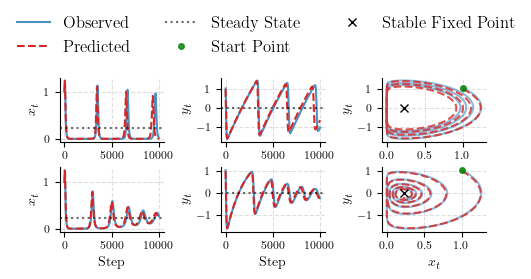

In [ ]:
x0=1
y0=0.5
z0=0
lr=0.01
alpha=0.1
beta=4
n_steps=10000
lambdas = [0.01, 0.05]

# Create 2x3 Subplots
fig, axes = plt.subplots(2, 3)
fig.subplots_adjust(wspace=0.55, hspace=0.4) # Give columns room to breathe

# Color scheme
color_obs = '#1f77b4'  
color_pred = '#d62728' 
color_steady = 'black'

for row, lam in enumerate(lambdas):
    # --- FETCH DATA ---
    # Replace these function calls with your actual toy_models calls
    data = toy_models.gd_run(
        x0=x0, y0=y0, z0=z0, lr=0.01, wd=lam, 
        alpha=alpha, beta=beta, n_steps=n_steps
    )
    predicted = toy_models.predict_dynamics(
        x0=x0, y0=y0, lr=0.01, wd=lam, 
        alpha=alpha, beta=beta, n_steps=n_steps
    )

    # --- PROCESS VARIABLES ---
    time_steps = np.arange(n_steps + 1)
    
    # Column 1 Data (u)
    u_obs = np.abs(np.vecdot(data["u"], data["xyz"], axis=1))
    u_pred = np.abs(predicted["x_pred"])
    u_steady = predicted["X_resting"]
    
    # Column 2 Data (\nabla S)
    grad_s_obs = np.vecdot(data["grad_S"], data["xyz"], axis=1)
    grad_s_pred = predicted["S_pred"] - 2/lr
    grad_s_steady = 0

    # --- PLOTTING ---
    
    # Col 1: u evolution
    ax_u = axes[row, 0]
    ax_u.plot(time_steps, u_obs, '-', color=color_obs, alpha=0.8, label='Observed')
    ax_u.plot(time_steps, u_pred, '--', color=color_pred, label='Predicted')
    ax_u.axhline(u_steady, color=color_steady, linestyle=':', alpha=0.6, label='Steady State')
    
    # Col 2: \nabla S evolution
    ax_s = axes[row, 1]
    ax_s.plot(time_steps, grad_s_obs, '-', color=color_obs, alpha=0.8)
    ax_s.plot(time_steps, grad_s_pred, '--', color=color_pred)
    ax_s.axhline(grad_s_steady, color=color_steady, linestyle=':', alpha=0.6)

    # Col 3: Phase Space (u vs \nabla S)
    ax_p = axes[row, 2]
    # Trajectories
    ax_p.plot(u_obs, grad_s_obs, '-', color=color_obs, alpha=0.5)
    ax_p.plot(u_pred, grad_s_pred, '--', color=color_pred, alpha=0.8)
    
    # Markers for Phase Space (Start and End)
    ax_p.plot(u_obs[0], grad_s_obs[0], 'go', markersize=4, label='Start Point', alpha=0.8)
    ax_p.plot(u_steady, grad_s_steady, 'kx', markersize=6, label='Stable Fixed Point')

    # --- FORMATTING & CLEANUP ---
    
    # ADDED: Y-labels for each column
    ax_u.set_ylabel(r'$x_t$')
    ax_s.set_ylabel(r'$y_t$')
    ax_p.set_ylabel(r'$y_t$')
    
    # Add X-labels only to the bottom row
    if row == len(lambdas) - 1:
        ax_u.set_xlabel('Step')
        ax_s.set_xlabel('Step')
        ax_p.set_xlabel(rf'$x_t$')

    # Grid and spines for all axes
    for ax in [ax_u, ax_s, ax_p]:
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 4. Legend Handling
# Grab handles from the first column (time series lines)
handles_time, labels_time = axes[0, 0].get_legend_handles_labels()

# Grab handles from the third column (phase space markers)
handles_phase, labels_phase = axes[0, 2].get_legend_handles_labels()

# Combine the handles and labels
handles = handles_time + handles_phase
labels = labels_time + labels_phase

# Place the unified legend at the top. 
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.92), ncol=3, frameon=False)

plt.savefig('plots/model_accuracy.pdf', format='pdf', bbox_inches='tight')
# 5. Export
plt.show()

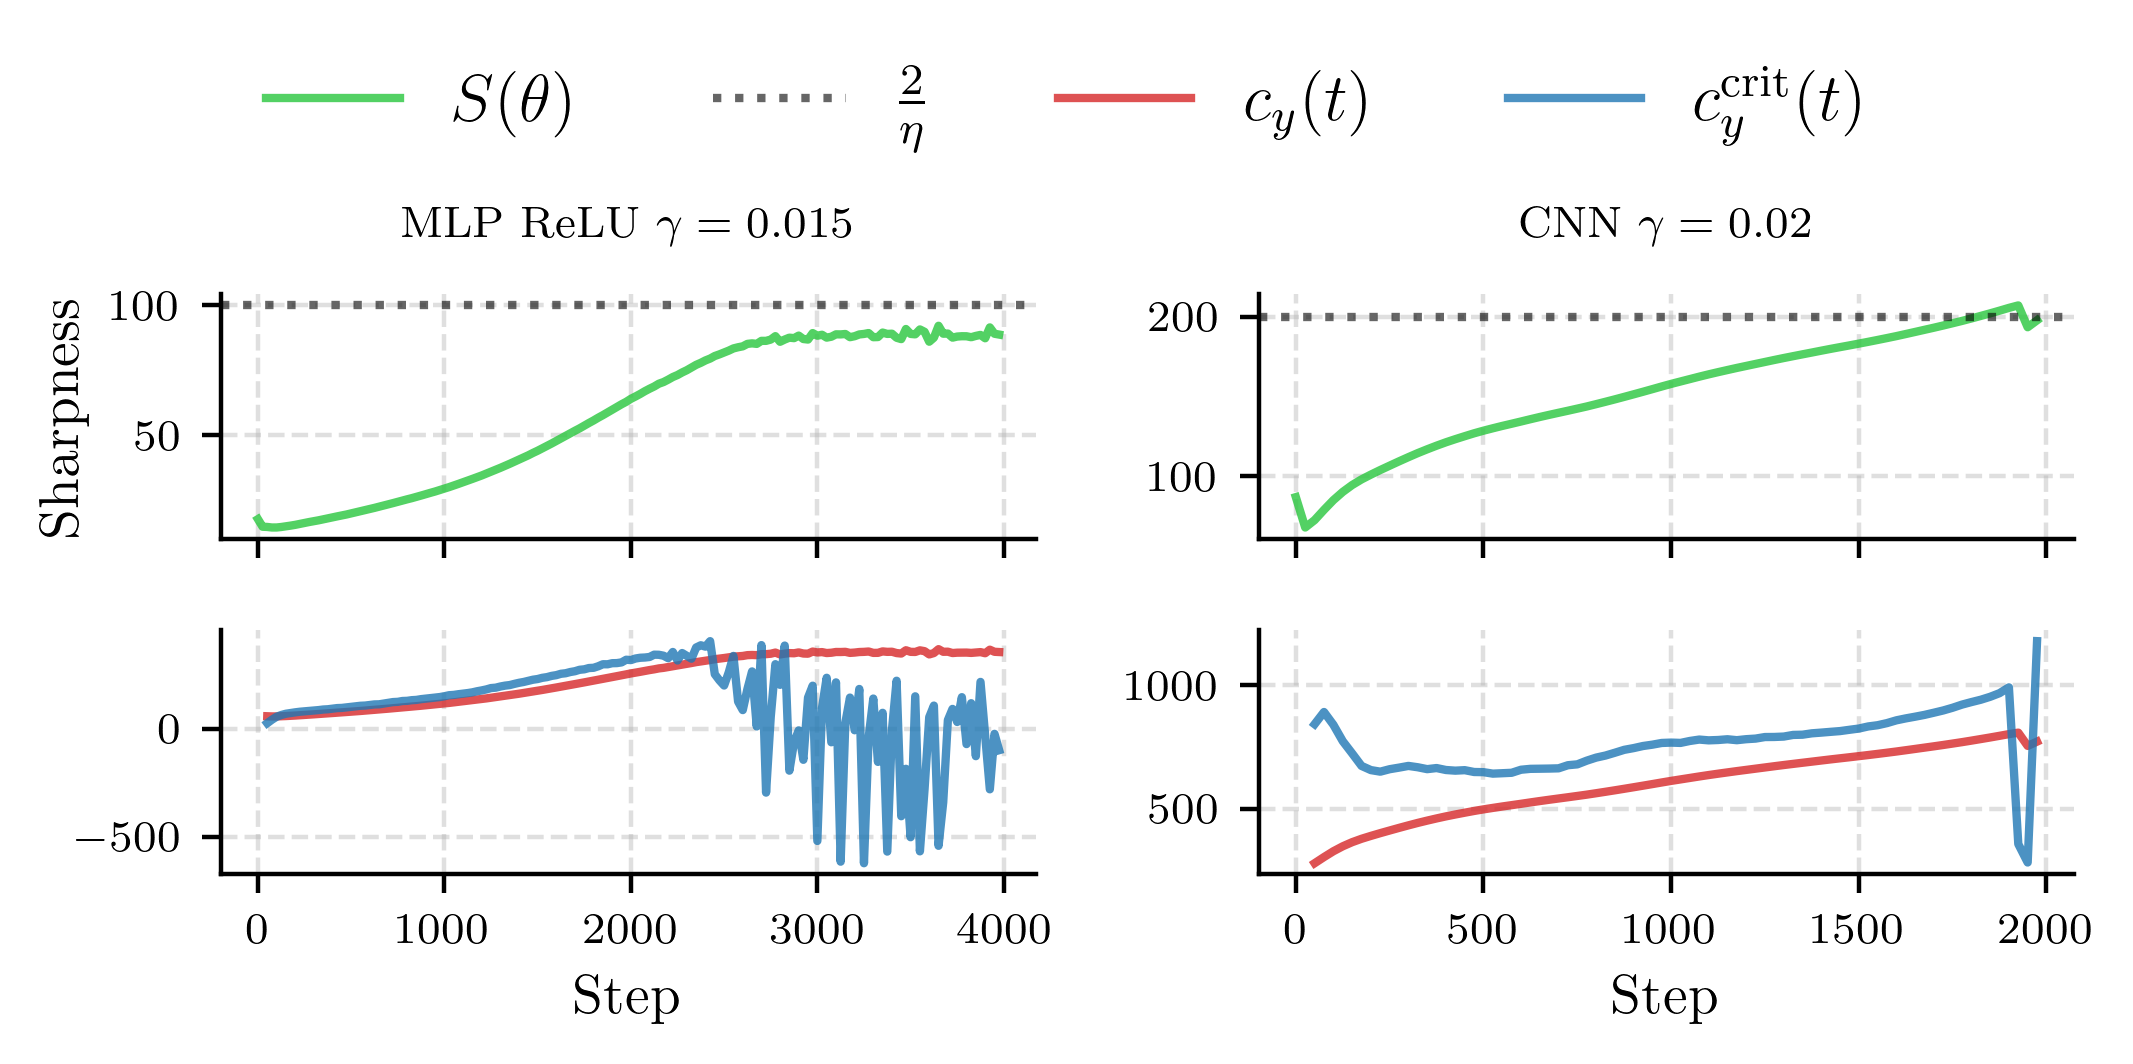

In [150]:
# --- 1. CONFIGURATION ---
freq = 25
color_blue = '#1f77b4'  
color_red = '#d62728' 

# Hyperparameters based on the paths provided
cnn_lr, cnn_wd = 0.01, 0.02
relu_lr, relu_wd = 0.02, 0.015

cnn_directory = "slt-results/cifar10-5k/cnn-relu/seed_11/mse/gd/lr_0.01/wd_0.02"
relu_directory = "slt-results/cifar10-5k/full_200/seed_11/mse/gd/lr_0.02/wd_0.015"

# --- 2. LOAD DATA ---
# (Fixed variable overwrite bugs here)
cnn_s = torch.load(f"{cnn_directory}/eigs_final.pt")
cnn_a = torch.load(f"{cnn_directory}/a_final.pt")
cnn_cy = torch.load(f"{cnn_directory}/cy_final.pt")

relu_s = torch.load(f"{relu_directory}/eigs_final.pt")
relu_a = torch.load(f"{relu_directory}/a_final.pt")
relu_cy = torch.load(f"{relu_directory}/cy_final.pt") # Fixed from relu_a

# Ensure tensors
cnn_s = torch.tensor(cnn_s) if not isinstance(cnn_s, torch.Tensor) else cnn_s
cnn_a = torch.tensor(cnn_a) if not isinstance(cnn_a, torch.Tensor) else cnn_a
cnn_cy = torch.tensor(cnn_cy) if not isinstance(cnn_cy, torch.Tensor) else cnn_cy

relu_s = torch.tensor(relu_s) if not isinstance(relu_s, torch.Tensor) else relu_s
relu_a = torch.tensor(relu_a) if not isinstance(relu_a, torch.Tensor) else relu_a
relu_cy = torch.tensor(relu_cy) if not isinstance(relu_cy, torch.Tensor) else relu_cy

# Isolate top eigenvalue if sharpness is 2D
cnn_s = cnn_s[:, 0] if cnn_s.ndim > 1 else cnn_s
relu_s = relu_s[:, 0] if relu_s.ndim > 1 else relu_s

# --- 3. PROCESS DYNAMICS ---
def get_crossing_step(cy, c_crit, x_vals, threshold_step=200):
    """Helper to find the first step where cy crosses c_crit"""
    mask = x_vals > threshold_step
    cy_masked = cy[mask]
    c_crit_masked = c_crit[mask]
    x_masked = x_vals[mask]

    diff = cy_masked - c_crit_masked
    sign_changes = (diff[:-1] * diff[1:]) < 0
    if sign_changes.any():
        first_idx = sign_changes.nonzero(as_tuple=True)[0][0].item()
        return x_masked[first_idx].item()
    return None

# Calculate derived metrics
cnn_x = torch.arange(len(cnn_a)) * freq
cnn_c_crit = cnn_a / cnn_wd + cnn_wd

relu_x = torch.arange(len(relu_a)) * freq
relu_c_crit = relu_a / relu_wd + relu_wd

# --- 4. PLOTTING ---
fig, axes = plt.subplots(2, 2, dpi=400, sharex='col')
fig.subplots_adjust(wspace=0.3, hspace=0.2)

# Column 0: ReLU
axes[0,0].set_title(r'MLP ReLU $\gamma=0.015$', fontsize=8, pad=10)
axes[0,0].plot(relu_x, relu_s, color="#28c63d", alpha=0.8, label=r'$S(\theta)$')
axes[0,0].axhline(2. / relu_lr, linestyle=':', color='black', alpha=0.6, label=r'$\frac{2}{\eta}$')

axes[1,0].plot(relu_x[2:], relu_cy[2:], color=color_red, alpha=0.8, label=r'$c_y(t)$')
axes[1,0].plot(relu_x[2:], relu_c_crit[2:], color=color_blue, alpha=0.8, label=r'$c_y^{\mathrm{crit}}(t)$')

# Column 1: CNN
axes[0,1].set_title(r'CNN $\gamma=0.02$', fontsize=8, pad=10)
axes[0,1].plot(cnn_x, cnn_s, color="#28c63d", alpha=0.8)
axes[0,1].axhline(2. / cnn_lr, linestyle=':', color='black', alpha=0.6)

axes[1,1].plot(cnn_x[2:], cnn_cy[2:], color=color_red, alpha=0.8)
axes[1,1].plot(cnn_x[2:], cnn_c_crit[2:], color=color_blue, alpha=0.8)

# --- 5. FORMATTING & CLEANUP ---
# Labels
axes[0,0].set_ylabel('Sharpness')
axes[1,0].set_xlabel('Step')
axes[1,1].set_xlabel('Step')

# Spines and Grid
for ax in axes.flatten():
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend Handling
# Extract handles from the ReLU plots to make a unified figure legend
handles_top, labels_top = axes[0,0].get_legend_handles_labels()
handles_bot, labels_bot = axes[1,0].get_legend_handles_labels()

handles = handles_top + handles_bot
labels = labels_top + labels_bot

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.92), ncol=4, frameon=False)

# Export
plt.tight_layout()
plt.savefig('plots/model_phaseshift.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Appendix A

/tmp/ipykernel_17501/3608177892.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu')


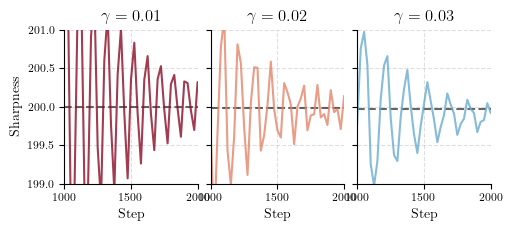

In [ ]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    # Width expanded to ~11 inches to comfortably fit 4 subplots
    "figure.figsize": (5.5, 2), 
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
})

# 2. Setup Data Parameters
dataset = "cifar10-5k"
arch = "cnn-relu"
loss = "mse"
gd_lr = 0.01
seed = '10_true'
freq = 25
threshold = 2 / gd_lr

# Decreasing gamma values as requested
wd_list = [0.01, 0.02, 0.03] 

# Generate 4 colorblind-friendly colors from RdBu
cmap = cm.get_cmap('RdBu')
gradient_colors = [cmap(0.05), cmap(0.25), cmap(0.75), cmap(0.95)] # Red to Blue

# 3. Create 1x4 Subplots (Sharing Y-axis to easily compare dampening magnitude)
fig, axes = plt.subplots(1, 3, sharey=True, sharex=True)

for ax, w_d, color in zip(axes, wd_list, gradient_colors):
    # Plot the threshold line
    ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.6, label=r"$\frac{2}{\eta}$" if ax == axes[-1] else "")
    
    # Extract Data
    results_dir = os.environ.get('RESULTS', 'slt-results')
    gd_directory = f"{results_dir}/{dataset}/{arch}/seed_{seed}/{loss}/gd/lr_{gd_lr}/wd_{w_d}"
    
    try:
        gd_s = torch.load(f"{gd_directory}/eigs_final.pt")
        sharpness = gd_s[:,0].numpy() if hasattr(gd_s, 'numpy') else np.array(gd_s)
        
        # Isolate data after crossing the threshold
        first_above = np.argmax(sharpness > threshold)
        if first_above > 0 or sharpness[0] > threshold:
            sharpness_cut = sharpness[first_above:]
            steps = np.arange(len(sharpness_cut)) * freq
            
            ax.plot(
                steps,
                sharpness_cut,
                linestyle='-',
                color=color,
                alpha=0.8
            )
    except FileNotFoundError:
        print(f"Warning: Could not find eigs_final.pt for wd={w_d}")

    # Formatting each axis
    ax.set_title(rf'$\gamma = {w_d}$', fontsize=12)
    ax.set_xlabel('Step')
    # ax.set_xlim(0, 2000)
    ax.set_xlim(1000, 2000)
    ax.set_ylim(199, 201)
    
    # Clean up grid and spines
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set Y-label only on the leftmost plot
axes[0].set_ylabel('Sharpness')

# 4. Export safely
# wspace reduces the gap between subplots since the y-axis is shared
plt.subplots_adjust(wspace=0.1) 
plt.savefig('plots/empirical_dampening.pdf', format='pdf', bbox_inches='tight')
plt.show()